# Independent Validation of a Credit-Risk Model
### German Credit dataset - a model-risk / model-validation walkthrough

**Author:** Mandeep Kour

---

## What is this project?

A bank uses a computer model to decide whether a loan applicant is a **good** credit risk
(likely to repay) or a **bad** credit risk (likely to default).

If the model is wrong, real money is lost and real people are treated unfairly. So a bank
does **not** just trust the people who built the model. A separate team checks it. That
team is called **Model Risk / Model Validation**, and their job is to be the **skeptic**.

In this notebook I play **two roles**:

1. **The Developer** - I build a credit-risk model (the thing being checked).
2. **The Validator** - then I switch hats and *challenge* that model the way any AI
   validation team would, asking: *Can I trust this thing?*

I check the model on five things a real validator checks:

| # | Check |  question |
|---|-------|----------------------------|
| 1 | **Conceptual soundness** | Does this model even make sense? |
| 2 | **Right metrics** | Is it *actually* good - or just good-looking? |
| 3 | **Reproducibility** | If I run it again, do I get the same answer? |
| 4 | **Robustness** | Does it stay sensible when the data wobbles a bit? |
| 5 | **Fairness** | Does it treat different groups of people consistently? |

---
### How to run this
Run the cells top to bottom (**Cell ▸ Run All**). It downloads the public *German Credit*
dataset automatically. You need an internet connection the first time.

## Section 0 - Setup

We load our tools and **fix the random seed**. A seed is like shuffling a deck of cards
the exact same way every time - it's the first step toward *reproducibility* (Check #3).

In [27]:
# === Core data tools ===
import numpy as np                 # for numbers and math (arrays, random noise, averages)
import pandas as pd                # for handling the data as a table (rows = applicants, columns = features)
import matplotlib.pyplot as plt    # for drawing the charts (confusion matrix, ROC curve, fairness bars)

# === Getting the dataset ===
from sklearn.datasets import fetch_openml   # downloads the public "German Credit" data for us automatically

# === Splitting and re-checking the data ===
from sklearn.model_selection import (
    train_test_split,    # splits data into a "learning/train" set and an unseen "exam/test" set
    cross_val_score,     # re-tests the model on several different slices, to make sure the score isn't a fluke
    StratifiedKFold,     # decides how those slices are made, keeping the good/bad ratio the same in each
)

# === Preparing the data so the model can read it ===
from sklearn.compose import ColumnTransformer            # lets us treat number columns and word columns differently
from sklearn.preprocessing import OneHotEncoder, StandardScaler
#   OneHotEncoder  -> turns words like "own home" into numbers the model can use
#   StandardScaler -> puts all numbers on the same scale (so big numbers like loan amount don't dominate)
from sklearn.pipeline import Pipeline                    # chains the prep steps + the model into one clean object

# === The two models we build ===
from sklearn.linear_model import LogisticRegression      # a simple, easy-to-explain model (good as a baseline)
from sklearn.ensemble import RandomForestClassifier      # a stronger model made of many decision "trees"

# === The validator's scorecard (how we judge the model) ===
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,  # the grid of right/wrong outcomes (+ a way to draw it)
    RocCurveDisplay,                           # draws the ROC curve (how well it separates good from bad)
    classification_report,                     # a tidy summary of precision, recall, and f1
    roc_auc_score,                             # one overall score: 1.0 = perfect, 0.5 = coin flip
    accuracy_score,                            # plain accuracy (we show WHY this one can mislead)
    recall_score,                              # of the truly risky people, how many did we catch? (key metric)
    precision_score,                           # of the people we flagged as risky, how many really were?
)

# === Reproducibility: the "same result every time" setting ===
RANDOM_STATE = 42          # a fixed seed = the deck is shuffled the exact same way each run, so results repeat
np.random.seed(RANDOM_STATE)             # locks the randomness for numpy too (used in the noise/robustness test)
pd.set_option("display.max_columns", 50) # just a display setting: show up to 50 columns instead of hiding some

print("Setup complete.")    # a simple confirmation that all tools loaded with no errors

Setup complete.


## Section 1 - Load the data

The **German Credit** dataset has information on 1,000 past loan applicants - their
account status, loan amount, age, job, and so on - plus the answer we care about:
were they a **good** or **bad** credit risk?

Think of it as 1,000 old loan files the bank already knows the outcome of. The model
tries to learn the pattern from these so it can judge *new* applicants.

In [28]:
# Download the public "German Credit" dataset straight from OpenML (a free online data library).
# It has 1,000 past loan applicants and 20 pieces of info about each one.
#   "credit-g"      -> the dataset's name (the German credit data)
#   version=1       -> pin to a specific version so the data never changes under us (helps reproducibility)
#   as_frame=True   -> give it back as a pandas table (rows + named columns), not raw arrays, so it's readable
# fetch_openml returns a bundle (data, target, descriptions, etc.)
data = fetch_openml("credit-g", version=1, as_frame=True)


# .frame is the full table with the features AND the answer column together.
# .copy() makes our own clean copy so anything we change doesn't affect the original download.
df = data.frame.copy()


# Quick sanity check: print how big the table is, as (number of rows, number of columns).
# We expect something like (1000, 21) -> 1,000 applicants, 20 features + 1 answer column ("class").
print("Shape (rows, columns):", df.shape)

# Show the first 5 rows so we can eyeball the data and confirm it loaded correctly.
# (.head() is just "show me the top of the table.")
df.head()

Shape (rows, columns): (1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,4,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,4,no known property,53,none,for free,2,skilled,2,none,yes,bad


| # | Column | What it means |
|---|--------|-------------------------------|
| 1 | **checking_status** | How much money is in their checking account |
| 2 | **duration** | How long the loan lasts, in months |
| 3 | **credit_history** | Their past record of repaying loans |
| 4 | **purpose** | What the loan is for (car, education, furniture…) |
| 5 | **credit_amount** | How much money they want to borrow |
| 6 | **savings_status** | How much they have in savings |
| 7 | **employment** | How long they've held their current job |
| 8 | **installment_commitment** | Loan payment as a % of income (how big a bite it takes) |
| 9 | **personal_status** | Marital status and sex |
| 10 | **other_parties** | Anyone else on the loan (co-signer or guarantor) |
| 11 | **residence_since** | How many years at their current address |
| 12 | **property_magnitude** | What property they own (real estate, car, none) |
| 13 | **age** | Applicant's age in years |
| 14 | **other_payment_plans** | Other loans/debts they're already paying off |
| 15 | **housing** | Whether they own, rent, or live for free |
| 16 | **existing_credits** | How many loans they already have at this bank |
| 17 | **job** | Skill level of their job (unskilled, skilled, management) |
| 18 | **num_dependents** | How many people depend on their income |
| 19 | **own_telephone** | Whether they have a registered phone (a stability signal) |
| 20 | **foreign_worker** | Whether they're a foreign worker (yes/no) |
| 21 | **class** | **The answer** i good or bad credit risk |

## Section 2 - Conceptual soundness *(Check #1: does this make sense?)*

Before touching any maths, a good validator just **reads the model**. Are the inputs
sensible reasons to judge someone's credit? Things like *checking account status*,
*loan duration*, *amount*, *savings*, and *job* are all reasonable - they're the kinds
of things a human loan officer would also look at. That's a good sign.

We also look at the **target balance**: how many applicants are "good" vs "bad". This
matters a lot for Check #2.

The answer column ('class') breaks down as:
class
good    700
bad     300
Name: count, dtype: int64

class
good    0.7
bad     0.3
Name: proportion, dtype: float64


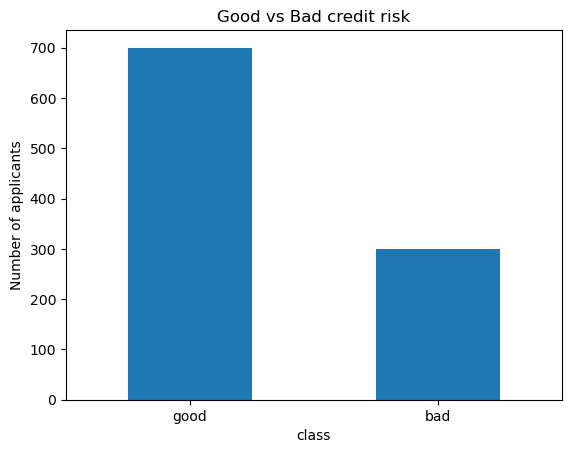

In [29]:
# Goal of this cell: look at the "answer" column ('class') and see how many applicants
# are GOOD credit risks vs BAD credit risks. This indicates whether the data is balanced or lopsided.

print("The answer column ('class') breaks down as:")

# value_counts() = count how many times each answer appears
print(df["class"].value_counts())

print()  # just to print a blank line

# Same thing, but normalize=True turns the counts into proportions (shares that add up to 1).
# .round(3) trims it to 3 decimals
print(df["class"].value_counts(normalize=True).round(3))

# Draw the same counts as a bar chart so it's easy to see at a glance.
#   kind="bar" -> bar chart                    title=...  -> the chart heading
#   rot=0      -> keep the x-axis labels flat (not tilted), so "good"/"bad" are easy to read
df["class"].value_counts().plot(kind="bar", title="Good vs Bad credit risk", rot=0)
plt.ylabel("Number of applicants")  # label the vertical axis so the chart is self-explanatory
plt.show()                          # actually display the chart

**Reading:** about **70%** of applicants are *good* and only **~30%**
are *bad*. That imbalance is a trap waiting to happen - remember it for the next section.

Quick sanity check that a couple of features behave the way common sense says they should
(e.g. people with no checking account or longer loans tend to be riskier).

In [30]:
# Does risk rise with loan duration? (longer loans = more chance to default)
df.groupby("class", observed=True)["duration"].mean().round(1)
#   df.groupby("class")  -> split the applicants into two piles: "good" and "bad"
#   observed=True        -> only group the categories that actually appear (tidy + avoids a warning
#                           on categorical columns; no empty groups)
#   ["duration"]         -> within each pile, look only at the loan-duration column (in months)
#   .mean()              -> average the duration for each pile
#   .round(1)            -> trim to 1 decimal place so it's easy to read

class
bad     24.9
good    19.2
Name: duration, dtype: float64

## Section 3 - Data quality *(part of Check #1)*

A model is only as trustworthy as the data behind it. We check for **missing values**
and **duplicate rows** - the two most common data problems. Garbage in, garbage out.

In [31]:
print("Missing values per column (should be 0):")
print(df.isnull().sum().sum(), "total missing values")
print()
print("Duplicate rows:", df.duplicated().sum())
print()
print("Numeric columns at a glance:")
df.describe().round(1)

Missing values per column (should be 0):
0 total missing values

Duplicate rows: 0

Numeric columns at a glance:


,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
mean,20.9,3271.3,3.0,2.8,35.5,1.4,1.2
std,12.1,2822.7,1.1,1.1,11.4,0.6,0.4
min,4.0,250.0,1.0,1.0,19.0,1.0,1.0
25%,12.0,1365.5,2.0,2.0,27.0,1.0,1.0
50%,18.0,2319.5,3.0,3.0,33.0,1.0,1.0
75%,24.0,3972.2,4.0,4.0,42.0,2.0,1.0
max,72.0,18424.0,4.0,4.0,75.0,4.0,2.0


## Section 4 - Build the model *(Developer)*

Now I put on the **Developer** hat and build the model that will later be validated.

Two quick prep steps:
- **Categories → numbers:** a model can't read words like *"own home"*, so we turn each
  category into numeric flags (*one-hot encoding*)
- **Put numbers on the same scale:** loan *amount* is in the thousands while *age* is in
  the tens. Scaling stops the big numbers from unfairly dominating

We define **"bad" = the thing we want to catch** (like catching fraud), so:
`1 = bad/risky`, `0 = good`. Then we hold back **25% of the data as a test set** the model
never sees during training - that's our honest exam

In [32]:
# === Step 1: Separate the "answer" from the "clues" ===

# Build the target y: the thing we're trying to predict
# (df["class"] == "bad") gives True/False for each applicant; .astype(int) turns that into 1/0
# We deliberately make 1 = "bad/risky" because that's the case we most want to CATCH
y = (df["class"] == "bad").astype(int)

# Build the features X: everything EXCEPT the answer
X = df.drop(columns=["class"])

In [33]:
# === Step 2: Sort the clues into two types, because they need different prep ===

# Number columns (age, loan amount, duration...) -> grabbed by "include number"
num_features = X.select_dtypes(include="number").columns.tolist()
# Word/category columns (housing, job, purpose...) -> "exclude number" grabs everything else
cat_features = X.select_dtypes(exclude="number").columns.tolist()
print("Numeric features:", num_features)
print()
print("Categorical features:", cat_features)

Numeric features: ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']

Categorical features: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']


In [34]:
# === Step 3: Define how to prepare each type so the model can read it ===
# ColumnTransformer = "apply different prep to different columns, all in one place."
preprocess = ColumnTransformer([
    # For numbers: StandardScaler puts them on the same scale, so a big number like
    # loan amount (thousands) doesn't unfairly outweigh a small one like age (tens)
    ("num", StandardScaler(), num_features),

    # For words: OneHotEncoder turns each category into 0/1 flag columns the model can use.
    #   handle_unknown="ignore" -> if a new, unseen category shows up later, don't crash
    #   sparse_output=False     -> return a normal table (some models dislike the compressed form)
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
])

In [35]:
# Hold back 25% as an unseen 'exam'. stratify keeps the good/bad ratio the same
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print(f"\nTraining on {len(X_train)} applicants, testing on {len(X_test)} unseen applicants.")


Training on 750 applicants, testing on 250 unseen applicants.


In [36]:
# A small reusable "factory" function so we build the model the SAME clean way every time,
# instead of copy-pasting the setup. Call it whenever you need a fresh, untrained model.
def build_model():
    # Logistic Regression: a simple, easy-to-explain model - a good, low-risk baseline.
    #   max_iter=1000     -> give it enough rounds to settle on an answer (avoids a "didn't finish" warning)
    #   random_state=...  -> fixed seed so it trains identically every run (reproducibility)
    clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

    # Glue the data-prep and the model into ONE object (a Pipeline), in order:
    #   "prep" -> the ColumnTransformer from before (scales numbers, one-hot encodes words)
    #   "clf"  -> the logistic regression model
    # Now anything we do (train, predict) automatically runs the prep first, every time.
    return Pipeline([("prep", preprocess), ("clf", clf)])

# === Put on the Developer hat: build and train the model that will be validated ===
# build_model() -> make a fresh pipeline; .fit(X_train, y_train) -> learn from the training data ONLY.
model = build_model().fit(X_train, y_train)

print("Model trained. Now we switch to the Validator hat.")

Model trained. Now we switch to the Validator hat.


## Section 5 - The right metrics *(Validator- Check #2)*

Here is the most important lesson in model risk.

A lazy model could just say **"everyone is good"**. Because 70% of people really are good,
that lazy model would be **70% accurate** - and **completely useless**, because it never
catches a single bad risk. This is the **accuracy trap**.

So a validator ignores plain accuracy and looks at:
- **Recall (on bad):** of the truly risky people, how many did we *catch*? (Most important here.)
- **Precision (on bad):** of the people we *flagged* as risky, how many really were?
- **ROC-AUC:** an overall score of how well the model separates good from bad (1.0 = perfect, 0.5 = coin flip).
- **A confusion matrix:** the four outcomes laid out in a simple grid.
- **Business cost:** in credit, lending to a bad applicant (a *miss*) hurts far more than
  rejecting a good one. The classic German Credit rule says a **miss is 5× worse**.

In [37]:
# === STEP 1: Show the "accuracy trap" using a lazy do-nothing model ===
# Pretend we built a lazy model that labels EVERYONE "good" (never flags any risk).
# (y_test == 0) is True for every applicant who is actually good; .mean() gives the share of them.
# Because most applicants ARE good, this lazy model scores high on accuracy even though it catches zero bad risks. That's the trap.
baseline_acc = (y_test == 0).mean()
print(f"Lazy 'everyone is good' model accuracy: {baseline_acc:.3f}  <-- looks fine, catches ZERO bad risks!\n")

# === STEP 2: Get our real model's answers on the unseen exam set ===
# .predict()  -> the model's yes/no decision for each applicant: 0 = good, 1 = bad
pred  = model.predict(X_test)
# .predict_proba()[:, 1] -> instead of a hard yes/no, the model's CONFIDENCE that each one is bad
#                           (a number from 0 to 1). We keep column [1] = the "bad" probability.
proba = model.predict_proba(X_test)[:, 1]


Lazy 'everyone is good' model accuracy: 0.700  <-- looks fine, catches ZERO bad risks!



In [38]:
# === STEP 3: Score the model the way a validator would (NOT just accuracy) ===

# Accuracy = of all applicants, how many did we label correctly? (Shown mainly to compare to the lazy baseline.)
print(f"Our model accuracy : {accuracy_score(y_test, pred):.3f}")

# Recall = of the truly BAD applicants, how many did we actually CATCH? (The key number here -
#          missing a bad loan is the costly mistake, so this is what a validator cares about most.)
print(f"Recall (caught bad): {recall_score(y_test, pred):.3f}   <-- the number a validator cares about most")

# Precision = of everyone we FLAGGED as bad, how many really were bad? (Guards against crying wolf.)
print(f"Precision (on bad) : {precision_score(y_test, pred):.3f}")

# ROC-AUC = one overall score for how well the model separates good from bad, across all thresholds.
#           1.0 = perfect, 0.5 = no better than a coin flip. Uses the confidence scores (proba), not the yes/no.
print(f"ROC-AUC            : {roc_auc_score(y_test, proba):.3f}")
print()

# === STEP 4: Print the full scorecard in one tidy table ===
# classification_report shows precision, recall, and f1 for BOTH classes at once.
#   target_names -> nice labels so the rows read "good (0)" / "bad (1)" instead of just 0/1.
print("Detailed report:")
print(classification_report(y_test, pred, target_names=["good (0)", "bad (1)"]))

Our model accuracy : 0.772
Recall (caught bad): 0.547   <-- the number a validator cares about most
Precision (on bad) : 0.641
ROC-AUC            : 0.804

Detailed report:
              precision    recall  f1-score   support

    good (0)       0.82      0.87      0.84       175
     bad (1)       0.64      0.55      0.59        75

    accuracy                           0.77       250
   macro avg       0.73      0.71      0.72       250
weighted avg       0.76      0.77      0.77       250



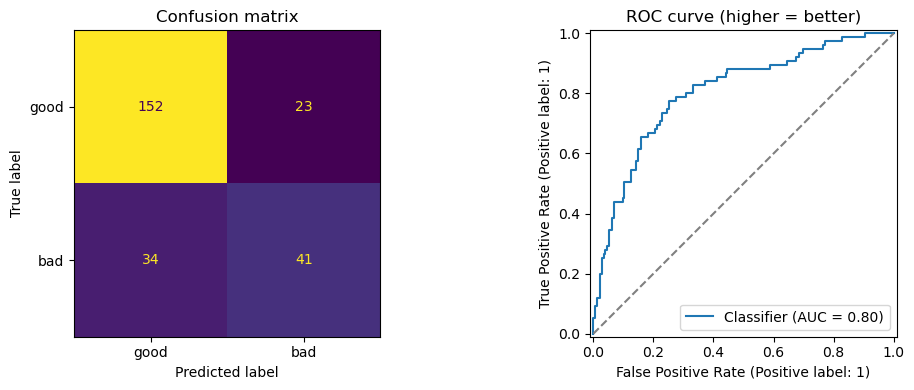

In [39]:
# Set up ONE canvas with TWO side-by-side spots for charts.
#   1, 2      -> a layout of 1 row and 2 columns (so the charts sit next to each other)
#   figsize   -> the overall size of the canvas in inches (11 wide, 4 tall)
#   fig       -> the whole canvas;  ax -> the two chart spots, ax[0] (left) and ax[1] (right)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# --- LEFT CHART: the confusion matrix (the grid of right/wrong outcomes) ---
# Compare the real answers (y_test) against the model's predictions (pred) and draw the 2x2 grid.
#   y_test                 -> what the applicants actually were (the truth)
#   pred                   -> what the model guessed
#   display_labels         -> label the boxes "good" / "bad" instead of 0 / 1, so it's readable
#   ax=ax[0]               -> draw it in the LEFT spot
#   colorbar=False         -> skip the colour scale bar on the side (keeps it clean)
ConfusionMatrixDisplay.from_predictions(
    y_test, pred, display_labels=["good", "bad"], ax=ax[0], colorbar=False)
ax[0].set_title("Confusion matrix")        # give the left chart a heading

# --- RIGHT CHART: the ROC curve (how well the model separates good from bad) ---
# This uses the model's CONFIDENCE scores (proba), not the hard yes/no, to draw the curve.
RocCurveDisplay.from_predictions(y_test, proba, ax=ax[1])
# Add a grey dashed diagonal line = the "pure guessing / no skill" reference.
# The more our curve pulls ABOVE this line, the better the model.
ax[1].plot([0, 1], [0, 1], "--", color="grey")
ax[1].set_title("ROC curve (higher = better)")   # give the right chart a heading

# Tidy up the spacing so the two charts don't overlap, then actually display them.
plt.tight_layout()
plt.show()

In [40]:
# === Turn the model's mistakes into a BUSINESS cost, not just a count ===
# Key idea: not all mistakes cost the same. Approving a bad borrower (a "miss") loses the whole loan
# Rejecting a good borrower (a "false alarm") only loses a bit of profit
# The classic German Credit rule says a miss is about 5x more costly than a false alarm.

# Take the 2x2 confusion-matrix grid and unpack its four boxes into four named numbers.
#   .ravel() just flattens the grid into a simple list, in this fixed order:
#   tn = True Negatives  -> good applicants correctly approved   (right ✅)
#   fp = False Positives -> good applicants wrongly REJECTED      (false alarm ⚠️)
#   fn = False Negatives -> bad applicants wrongly APPROVED       (miss ❌ - the costly one)
#   tp = True Positives  -> bad applicants correctly caught       (right ✅)
tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

# Add up a weighted "cost score":
#   each false alarm counts as 1  (mildly annoying - lost a good customer)
#   each miss counts as 5         (painful - handed out a loan that won't be repaid)
cost = fp * 1 + fn * 5

# Print the two mistake types separately, plus the combined weighted cost.
print(f"False alarms (good rejected): {fp}")
print(f"Misses (bad approved)       : {fn}")
print(f"Weighted business cost (FP*1 + FN*5) = {cost}")

# A validator's takeaway: even a decent-looking model still lets some bad risks through,
# and those misses are exactly the expensive ones the bank should worry about.
print("\nA validator would note: this model still MISSES some bad risks, which are the costly ones.")

False alarms (good rejected): 23
Misses (bad approved)       : 34
Weighted business cost (FP*1 + FN*5) = 193

A validator would note: this model still MISSES some bad risks, which are the costly ones.


**Finding:** the headline accuracy is *not* much better than the lazy
baseline - proof that accuracy alone is misleading. What matters is whether we **catch the
bad risks (recall)**, and how costly the **misses** are. This is the kind of nuance a
validator must surface to leadership.

I didn't just count errors - I weighted them by business cost, because approving a bad loan is far more damaging than rejecting a good applicant. Using the standard 5-to-1 cost, I showed that the model still allowed some costly misses through. Translating model mistakes into business impact is exactly how a validator makes a risk finding land with leadership

##Section 6 - Reproducibility *(Check #3: same answer twice?)*

If a bank can't reproduce a model's results, it can't trust or audit them. We rebuild the
exact same model with the same seed and confirm we get **identical** predictions. Then we
use **cross-validation** (testing on several different slices of data) to confirm the
score isn't a fluke of one lucky split.

In [41]:
# === TEST 1: Reproducibility - do we get the EXACT same model twice? ===
# Build a brand-new model from scratch and train it the same way as before.
# Because we use the same fixed seed (RANDOM_STATE), it should come out identical.
model_again = build_model().fit(X_train, y_train)

# Compare the new model's confidence scores to the original model's (proba) on the same exam set.
#   np.allclose(...) -> "are these two sets of numbers essentially identical?" -> True / False
identical = np.allclose(model_again.predict_proba(X_test)[:, 1], proba)
print("Re-running with the same seed gives identical results:", identical)

# === TEST 2: Stability - is the good score a fluke of one lucky split? ===
# Cross-validation re-tests the model on 5 DIFFERENT slices of the data, so we're not
# trusting a single train/test split that might have been unusually easy or hard.
#   StratifiedKFold -> chops the data into 5 folds, keeping the good/bad ratio in each
#   n_splits=5      -> use 5 folds
#   shuffle=True    -> mix the data before splitting (so folds aren't biased by row order)
#   random_state    -> fixed seed so the folds are the same every run (reproducible)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Train + score the model 5 times, once per fold, and collect the 5 scores.
#   build_model()         -> a fresh pipeline for each fold
#   X, y                  -> the WHOLE dataset (cross_val_score handles the splitting itself)
#   cv=cv                 -> use the 5-fold plan above
#   scoring="roc_auc"     -> grade each fold by ROC-AUC (separates good from bad)
scores = cross_val_score(build_model(), X, y, cv=cv, scoring="roc_auc")

# Show all 5 scores, then their average and how much they wobble (the spread/standard deviation).
print(f"\nROC-AUC across 5 folds: {scores.round(3)}")
print(f"Average: {scores.mean():.3f}  (spread ±{scores.std():.3f})")

Re-running with the same seed gives identical results: True

ROC-AUC across 5 folds: [0.775 0.753 0.796 0.807 0.801]
Average: 0.786  (spread ±0.020)


## Section 7 - Robustness *(Check #4: does it wobble?)*

Real-world data is never perfectly clean. A trustworthy model shouldn't flip its decision
because a number changed by a tiny amount. We test this two ways:

1. **Nudge the numbers by 5%** (small random noise) and see how many decisions *flip*.
   A low flip-rate is good - it means the model is stable, not jumpy.
2. **Re-train on several different random splits** and check the score barely moves.

In [42]:
# === ROBUSTNESS TEST: does the model stay calm when the data wobbles slightly? ===
# Real-world data is never perfectly precise - incomes get rounded, ages are approximate, etc.
# A trustworthy model shouldn't flip its decision just because a number changed a tiny bit.

# Set up a random-number generator with our fixed seed, so the "wobble" is the same every run (reproducible).
rng = np.random.default_rng(RANDOM_STATE)

# Make a separate COPY of the exam set so we don't damage the original data.
X_test_noisy = X_test.copy()

# Go through each NUMBER column (age, loan amount, duration...) and gently jiggle the values.
for c in num_features:
    #   rng.normal(0, 0.05, ...) -> small random nudges averaging 0, typically about ±5%
    #   (1 + nudge)              -> multiply each value by ~0.95 to ~1.05, i.e. shift it by roughly 5%
    # So every number gets a small, realistic wobble - nothing dramatic.
    X_test_noisy[c] = X_test_noisy[c] * (1 + rng.normal(0, 0.05, len(X_test_noisy)))

# Ask the SAME trained model to judge the slightly-wobbled applicants.
pred_noisy = model.predict(X_test_noisy)

# Compare the new decisions to the original ones and measure how many FLIPPED (good<->bad).
#   (pred_noisy != pred) -> True wherever the decision changed; .mean() -> the share that changed
flip_rate = np.mean(pred_noisy != pred)
print(f"Decisions that flipped under 5% noise: {flip_rate:.1%}")
print("(Lower is better - it means the model is stable, not over-sensitive.)")

Decisions that flipped under 5% noise: 1.2%
(Lower is better - it means the model is stable, not over-sensitive.)


In [43]:
# === STABILITY TEST: is the good score real, or did we just get one lucky split? ===
# Earlier we trained on ONE particular 75/25 split. What if that split happened to be easy?
# Here we redo the whole thing 5 times with 5 DIFFERENT random splits and see if the score holds.

aucs = []                       # an empty list to collect the 5 scores as we go

for s in range(5):              # loop 5 times, with s = 0, 1, 2, 3, 4 (a different split each time)
    # Make a fresh train/test split. The only thing that changes each loop is random_state=s,
    # so each round shuffles the applicants differently into "learn" vs "exam" piles.
    #   test_size=0.25 -> hold back 25% as the exam set
    #   stratify=y     -> keep the same good/bad ratio in both piles (fair split)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=s)

    # Build a brand-new model and train it on THIS round's training data only.
    m = build_model().fit(Xtr, ytr)

    # Score it on THIS round's unseen exam set, using ROC-AUC, and add that score to the list.
    #   m.predict_proba(Xte)[:, 1] -> the model's confidence that each test applicant is "bad"
    aucs.append(roc_auc_score(yte, m.predict_proba(Xte)[:, 1]))

# Show all 5 scores side by side...
print("ROC-AUC across 5 random splits:", [round(a, 3) for a in aucs])
# ...then the average score and how much they wobble (the spread / standard deviation).
# A SMALL spread = the model performs consistently no matter how the data is split = reliable.
print(f"Average {np.mean(aucs):.3f}, spread ±{np.std(aucs):.3f}  -> a small spread means it's reliable.")

ROC-AUC across 5 random splits: [0.794, 0.796, 0.771, 0.79, 0.794]
Average 0.789, spread ±0.009  -> a small spread means it's reliable.


## Section 8 - Fairness *(Check #5: is everyone treated consistently?)*

This is where model risk gets serious. A model can be accurate *overall* yet quietly treat
one group worse. We split the results by **age group** (a well-known sensitive feature in
this dataset) and compare:

- **Flag rate:** how often each group is labelled "bad / rejected".
- **False-rejection rate:** how often each group is *wrongly* rejected (they were actually good).

If one group is wrongly rejected far more often, that's a **fairness red flag** a validator
must escalate.

,group,n,flagged_bad_rate,false_rejection_rate
0,older (>25),196,0.224,0.122
1,young (<=25),54,0.370,0.185


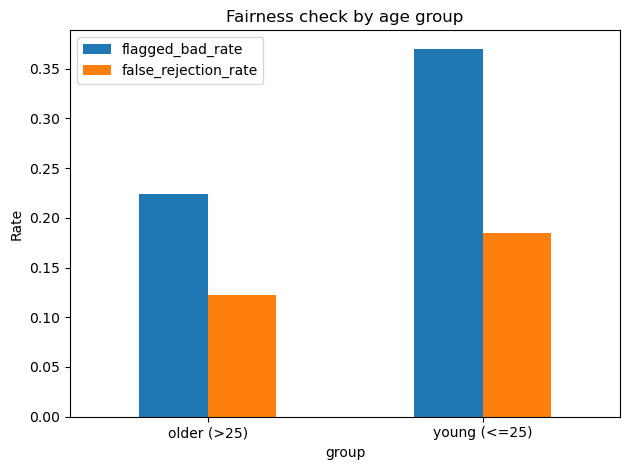

In [44]:
# === FAIRNESS TEST: Does the model treat younger and older applicants consistently? ===
# A model can look fine overall yet quietly be harder on one group. Here we split the results by age and compare,
# to see if the model penalises youth rather than true risk

# Make a working copy of the exam set so we don't touch the original data.
results = X_test.copy()
results["actual"] = y_test.values     # the TRUTH for each applicant: 1 = was actually bad, 0 = actually good
results["pred"]   = pred              # the MODEL'S decision:          1 = flagged bad, 0 = approved

# Tag each applicant as "young" or "older" based on age.
results["group"]  = np.where(results["age"] <= 25, "young (<=25)", "older (>25)")

summary = []                          # we'll collect one row of stats per group here

# Split the applicants into the two age groups and look at each group on its own.
for g, sub in results.groupby("group"):
    n = len(sub)                                  # how many applicants are in this group

    # Flag rate = of THIS group, what share did the model label "bad"?
    # (pred is 1/0, so the average = the proportion flagged bad.)
    flag_rate = sub["pred"].mean()

    # Now zoom in on only the people in this group who were ACTUALLY good (actual == 0).
    goods = sub[sub["actual"] == 0]

    # False-rejection rate = of those genuinely-good people, what share did the model
    # WRONGLY flag as bad? This is the unfairness we care about most: punishing good people.
    #   "if len(goods) else 0" just avoids dividing by zero if a group had no good applicants.
    false_reject = (goods["pred"] == 1).mean() if len(goods) else 0

    # Save this group's numbers as one tidy row.
    summary.append({"group": g, "n": n,
                    "flagged_bad_rate": round(flag_rate, 3),
                    "false_rejection_rate": round(false_reject, 3)})

# Turn the collected rows into a small table and show it.
fairness = pd.DataFrame(summary)
display(fairness)

# Draw the same two rates as side-by-side bars per group, so any gap is obvious at a glance.
fairness.set_index("group")[["flagged_bad_rate", "false_rejection_rate"]].plot(
    kind="bar", rot=0, title="Fairness check by age group")
plt.ylabel("Rate"); plt.tight_layout(); plt.show()

**Finding:** if the *young* group is flagged and wrongly rejected at a noticeably higher rate, the model may be **penalising youth** rather than true risk. A validator would flag this, ask the developers to investigate, and recommend a fairness
mitigation before the model is trusted in production. *(Your exact numbers will appear when you run the cell - report what you actually see.)*

## Section 9 - Validation summary *(the validator's report card)*

A real validation ends with a clear, honest summary - not a single score. Here is the
model-risk style write-up of everything we checked.

In [45]:
# === THE VALIDATION REPORT CARD (cleanly displayed) ===
report = pd.DataFrame([
    ["1. Conceptual soundness", "Are the inputs sensible reasons to judge credit?",
     "Pass - features are reasonable credit factors."],
    ["2. Right metrics",        "Is it genuinely good, not just good-looking?",
     "Caution - accuracy is misleading; judge by recall on 'bad' & cost of misses."],
    ["3. Reproducibility",      "Same result when re-run?",
     "Pass - identical with fixed seed; stable across cross-validation."],
    ["4. Robustness",           "Stable under small data changes?",
     "Review - see flip-rate & score spread above; flag if high."],
    ["5. Fairness",             "Consistent across groups?",
     "Flag - check the age-group gap above; escalate if large."],
], columns=["Validation check", "Question asked", "Finding"])

# Stop pandas from cutting off long text with "..."
pd.set_option("display.max_colwidth", None)

# Show it as a clean table: no index numbers, left-aligned, with a bit of styling.
report.style.hide(axis="index") \
    .set_properties(**{"text-align": "left", "white-space": "normal"}) \
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left"),
                                     ("background-color", "#f2f2f2"),
                                     ("font-weight", "bold")]}
    ])

Validation check,Question asked,Finding
1. Conceptual soundness,Are the inputs sensible reasons to judge credit?,Pass - features are reasonable credit factors.
2. Right metrics,"Is it genuinely good, not just good-looking?",Caution - accuracy is misleading; judge by recall on 'bad' & cost of misses.
3. Reproducibility,Same result when re-run?,Pass - identical with fixed seed; stable across cross-validation.
4. Robustness,Stable under small data changes?,Review - see flip-rate & score spread above; flag if high.
5. Fairness,Consistent across groups?,Flag - check the age-group gap above; escalate if large.
